# 06 - Does memory actually degrade before an OUT_OF_MEMORY kill?

Every telemetry result so far has been weak, with one exception: `OUT_OF_MEMORY` is
the **only** failure mode where node telemetry beats job metadata (8.07x against
4.15x at the 2 h horizon in `02`). That is also the mode with the clearest physical
mechanism - a job runs out of memory, so memory ought to be visibly running out.

But every telemetry feature in this project so far has been a **level**: the mean,
min, max or standard deviation of a metric inside one 20-minute window. None of them
encodes *change over time*. If degradation is real but gradual, a level summary can
miss it entirely while a baseline-relative one would catch it.

This notebook is a **mechanistic check, not a model**. It asks one question directly:
does memory drift before an OOM kill, and does it drift differently from jobs that
complete normally?

## Why this uses raw snapshots rather than windows

The median OOM job runs for **11 minutes**. A window needs 40 consecutive snapshots
= 20 minutes, so most OOM jobs never produce one and are invisible in
`eda/data/windows.parquet` - only 57 of 130 appear there at all. Working from raw
snapshots keeps the whole population and gives 30-second resolution.

## The confound that has to be handled

`experiments/` established that node telemetry is **shared**: on `*_shared` queues,
one node measurement is copied onto every co-resident job. `node_memory_MemFree_bytes`
is the **node's** free memory, not the job's. If an OOM job shares a node with three
healthy ones, the trace mixes all four.

So every result below is reported twice: on all OOM jobs, and on the **exclusive**
queues (`gpu`, `gpu_titanrtx`) where multiplicity is exactly 1 and the telemetry
belongs to that job alone. The exclusive subset is small - that is stated rather than
hidden.

## Pre-registration

**O1.** If degradation is real, node free memory falls, and active memory rises,
toward the end of OOM jobs but not toward the end of COMPLETED jobs of similar
length and queue.

**O2.** The effect will be clearer **relative to each job's own baseline** than in
absolute terms, because nodes differ in how much memory they have and in what else is
running on them.

**O3.** The effect will be clearer on exclusive queues, where the trace is not mixed
with co-tenants.

**Sample size is the binding constraint and is not fixable.** There are 130 OOM jobs
in the whole dataset and 22 of them on exclusive queues. A clear effect would still
come with wide intervals. The realistic outcome of this notebook is evidence about a
*mechanism*, not a detector.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.compute as pc
import matplotlib.pyplot as plt
from scipy.stats import rankdata

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW  = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

EXCLUSIVE_QUEUES = ("gpu", "gpu_titanrtx")
METRICS = {
    "node_memory_MemFree_bytes":        ("node free memory", 1 / 2**30, "GiB"),
    "node_memory_Active_bytes":         ("node active memory", 1 / 2**30, "GiB"),
    "node_memory_Dirty_bytes":          ("node dirty pages", 1 / 2**20, "MiB"),
    "nvidia_gpu_memory_used_bytes_sum": ("GPU memory used", 1 / 2**30, "GiB"),
}
BASELINE_S = 300.0      # each job's own reference = its first 5 minutes
MIN_RUNTIME_S = 900.0   # a job needs 15 min of telemetry to show a trend at all

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print("setup ok")

setup ok


## Step 1 - Choose the jobs: OOM, plus matched controls

Controls are COMPLETED jobs drawn from the **same queues** and a comparable runtime
range, so that any difference cannot be explained by "OOM jobs run longer" or "OOM
jobs live on busier queues".

In [2]:
jobs = pd.read_parquet(EDA / "jobs.parquet")
jobs["klass"] = np.where(jobs.nodetypes.astype(str).isin(EXCLUSIVE_QUEUES),
                         "exclusive", "shared")
jobs["runtime_s"] = jobs.tele_h * 3600

oom = jobs[(jobs.state.astype(str) == "OUT_OF_MEMORY") & (jobs.runtime_s >= MIN_RUNTIME_S)]
print(f"OOM jobs total {int((jobs.state.astype(str)=='OUT_OF_MEMORY').sum()):,}   "
      f"with >= {MIN_RUNTIME_S/60:.0f} min of telemetry: {len(oom):,}")
print(f"  of those, on exclusive queues: {int((oom.klass=='exclusive').sum()):,}")

# match controls on queue and on a log-runtime band
lo, hi = oom.runtime_s.min(), oom.runtime_s.max()
comp = jobs[(jobs.state.astype(str) == "COMPLETED") &
            (jobs.runtime_s.between(lo, hi)) &
            (jobs.nodetypes.astype(str).isin(oom.nodetypes.astype(str).unique()))]
rng = np.random.default_rng(0)
comp = comp.sample(min(len(comp), 400), random_state=0)

fail = jobs[(jobs.state.astype(str) == "FAILED") & (jobs.runtime_s.between(lo, hi))]
fail = fail.sample(min(len(fail), 200), random_state=0)

sel = pd.concat([oom, comp, fail])
print(f"\nselected: OOM {len(oom)}, COMPLETED {len(comp)}, FAILED {len(fail)}  "
      f"-> {len(sel)} jobs")
print(f"runtime band {lo/60:.1f} - {hi/60:.1f} min")
print()
print(sel.groupby([sel.state.astype(str), "klass"]).size().to_string())

OOM jobs total 130   with >= 15 min of telemetry: 62
  of those, on exclusive queues: 12

selected: OOM 62, COMPLETED 400, FAILED 200  -> 662 jobs
runtime band 15.0 - 5422.5 min

state          klass    
COMPLETED      exclusive      6
               shared       394
FAILED         exclusive     15
               shared       185
OUT_OF_MEMORY  exclusive     12
               shared        50


## Step 2 - Read the raw snapshots for exactly those jobs

In [3]:
d  = ds.dataset(RAW, format="parquet")
tb = d.to_table(columns=["slurm_id", "node", "timestamp"] + list(METRICS),
                filter=(pc.field("gpu_node") == 1) &
                       (pc.field("slurm_id").isin(sel.slurm_id.tolist())))
S = tb.to_pandas()
del tb
print(f"snapshots read: {len(S):,}   [{time.time()-t0:.0f}s]")

S = S.merge(sel[["slurm_id", "state", "nodetypes", "klass", "end_date", "start_date"]],
            on="slurm_id", how="inner")
S["state"] = S.state.astype(str)
S["ttf_s"] = (S.end_date - S.timestamp).dt.total_seconds()      # time to job end
S["elapsed_s"] = (S.timestamp - S.start_date).dt.total_seconds()
S = S[(S.ttf_s >= 0) & (S.elapsed_s >= 0)]
print(S.groupby("state").agg(snapshots=("slurm_id", "size"),
                             jobs=("slurm_id", "nunique")).to_string())

snapshots read: 432,272   [0s]
               snapshots  jobs
state                         
COMPLETED         204400   400
FAILED            155573   200
OUT_OF_MEMORY      72299    62


## Step 3 - Baseline-relative traces

For each `(job, node)` series, the reference value is the **median over that job's
first 5 minutes**. Every reading is then expressed as a change from that reference.
This is the feature family that has never been tested in this project: not "how much
memory is free" but "how much has this job's memory moved since it started".

In [4]:
S = S.sort_values(["slurm_id", "node", "timestamp"]).reset_index(drop=True)

# The reference is the median of each series' FIRST 10 SNAPSHOTS. An earlier version
# used "snapshots inside the first 5 minutes of start_date", which discarded two thirds
# of jobs whose telemetry begins later than that. Every baseline is computed in ONE
# pass: computing them inside a loop that also merges into S re-indexes S between
# iterations and silently misaligns the mask.
BASE_N = 10
first = S.groupby(["slurm_id", "node"], observed=True).head(BASE_N)
base = first.groupby(["slurm_id", "node"], observed=True)[list(METRICS)].median()
base.columns = [c + "__base" for c in base.columns]
S = S.merge(base, on=["slurm_id", "node"], how="left")
for col in METRICS:
    S[col + "__delta"] = S[col] - S[col + "__base"]

have = S[[c + "__delta" for c in METRICS]].notna().all(axis=1)
print(f"snapshots before baseline filter {len(S):,}  after {int(have.sum()):,}")
S = S[have].reset_index(drop=True)
print(S.groupby("state").agg(snapshots=("slurm_id", "size"),
                             jobs=("slurm_id", "nunique")).to_string())
facts["oom_jobs_analysed"] = int(S.loc[S.state == "OUT_OF_MEMORY", "slurm_id"].nunique())

snapshots before baseline filter 432,272  after 432,272
               snapshots  jobs
state                         
COMPLETED         204400   400
FAILED            155573   200
OUT_OF_MEMORY      72299    62


## Step 4 - The precursor plot

Median trace with an interquartile band, against **time remaining before the job
ends**. Time runs right to left: zero is the moment of death. If O1 holds, the OOM
curve separates from COMPLETED as zero is approached.

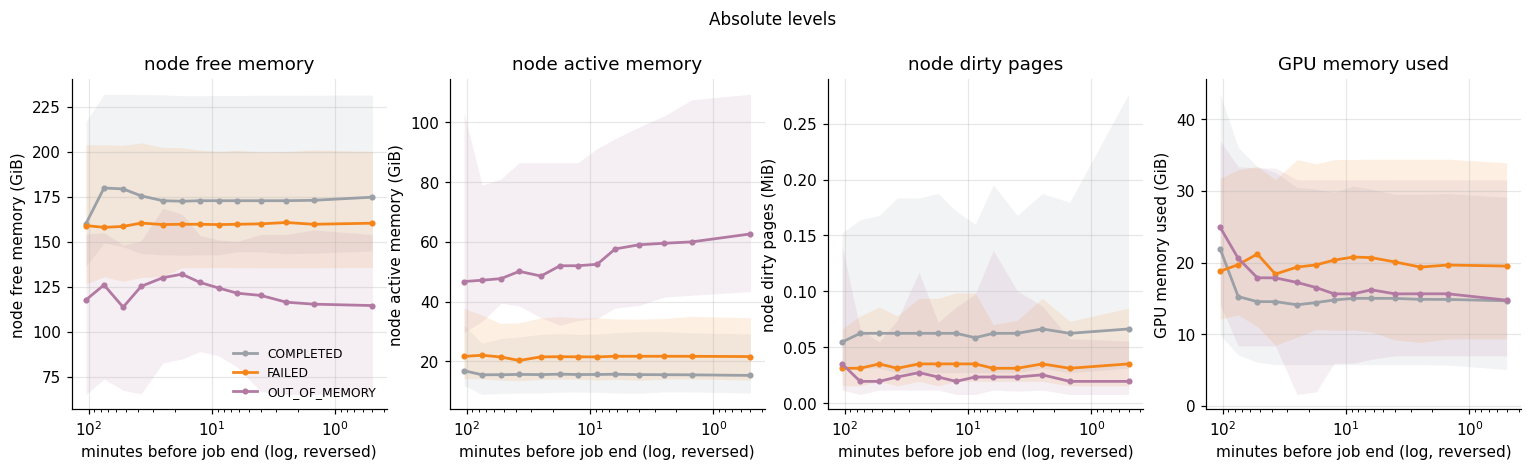

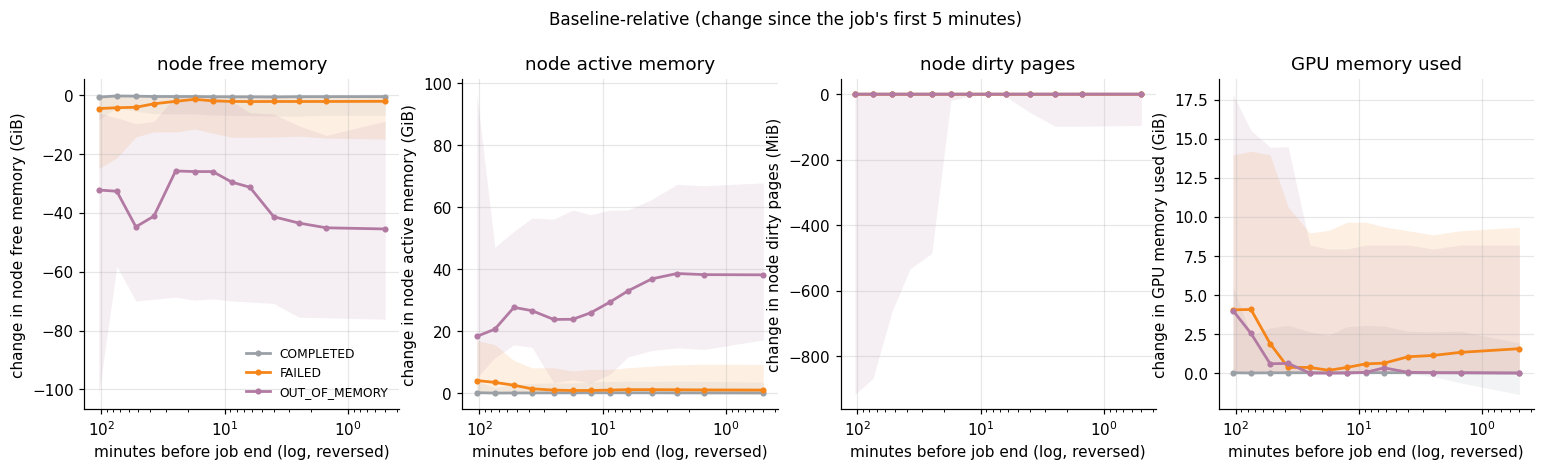

In [5]:
BINS = np.array([0, 60, 120, 180, 300, 450, 600, 900, 1200, 1800, 2700, 3600, 5400, 7200])
COLOR = {"OUT_OF_MEMORY": "#b279a2", "COMPLETED": "#9aa0a6", "FAILED": "#f58518"}

def trace_panel(ax, df, col, title, scale, unit, delta):
    key = col + "__delta" if delta else col
    sub = df[df.ttf_s <= BINS[-1]].copy()
    sub["bin"] = pd.cut(sub.ttf_s, BINS, right=False)
    for st in ["COMPLETED", "FAILED", "OUT_OF_MEMORY"]:
        g = sub[sub.state == st].groupby("bin", observed=True)[key]
        med, q1, q3 = g.median() * scale, g.quantile(.25) * scale, g.quantile(.75) * scale
        x = np.array([iv.left + (iv.right - iv.left) / 2 for iv in med.index]) / 60
        ax.plot(x, med, "o-", color=COLOR[st], lw=1.8, ms=3, label=st)
        ax.fill_between(x, q1, q3, color=COLOR[st], alpha=.12, lw=0)
    ax.invert_xaxis()
    ax.set(xscale="log", xlabel="minutes before job end (log, reversed)",
           ylabel=f"{'change in ' if delta else ''}{title} ({unit})", title=title)

for delta in [False, True]:
    fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))
    for ax, (col, (title, scale, unit)) in zip(axes, METRICS.items()):
        trace_panel(ax, S, col, title, scale, unit, delta)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle("Baseline-relative (change since the job's first 5 minutes)" if delta
                 else "Absolute levels", y=1.04, fontsize=11)
    save(fig, f"06_oom_{'delta' if delta else 'absolute'}.png"); plt.show()

## Step 5 - Exclusive queues only

Here the node telemetry belongs to one job. Few jobs survive this filter, so the
bands are wide - the plot is shown because a mixed trace cannot settle the question
either way, not because this subset is large enough to settle it alone.

               snapshots  jobs
state                         
COMPLETED           2315     6
FAILED             16569    15
OUT_OF_MEMORY      14301    12


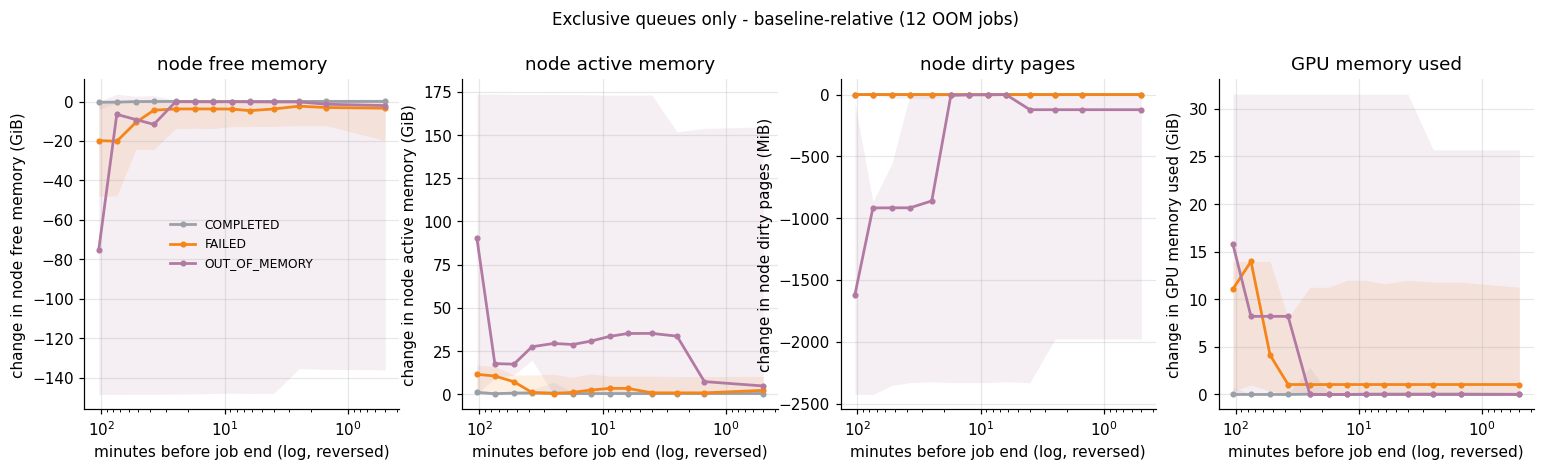

In [6]:
E = S[S.klass == "exclusive"]
print(E.groupby("state").agg(snapshots=("slurm_id", "size"),
                             jobs=("slurm_id", "nunique")).to_string())
facts["oom_jobs_exclusive"] = int(E.loc[E.state == "OUT_OF_MEMORY", "slurm_id"].nunique())

fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))
for ax, (col, (title, scale, unit)) in zip(axes, METRICS.items()):
    trace_panel(ax, E, col, title, scale, unit, True)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Exclusive queues only - baseline-relative "
             f"({facts['oom_jobs_exclusive']} OOM jobs)", y=1.04, fontsize=11)
save(fig, "06_oom_exclusive.png"); plt.show()

## Step 6 - Does it separate? Single-feature AUC in the last 5 minutes

For every snapshot in the final 5 minutes of a job, can a single number tell an OOM
job from a COMPLETED one? Reported for the absolute level and for the
baseline-relative change, so O2 can be read off directly.

AUC is computed by rank sum (Mann-Whitney) and the interval comes from a bootstrap
**over jobs**, since snapshots inside a job are not independent.

In [7]:
def auc_ci(pos, neg, groups_pos, groups_neg, n_boot=200, seed=0):
    def auc(a, b):
        r = rankdata(np.concatenate([a, b]))
        return (r[:len(a)].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b))
    base = auc(pos, neg)
    rng = np.random.default_rng(seed)
    up, un = np.unique(groups_pos), np.unique(groups_neg)
    ip = {g: np.flatnonzero(groups_pos == g) for g in up}
    iN = {g: np.flatnonzero(groups_neg == g) for g in un}
    out = []
    for _ in range(n_boot):
        a = np.concatenate([ip[g] for g in rng.choice(up, len(up))])
        b = np.concatenate([iN[g] for g in rng.choice(un, len(un))])
        out.append(auc(pos[a], neg[b]))
    return base, *np.percentile(out, [2.5, 97.5])

rows = []
for scope, df in [("all queues", S), ("exclusive only", S[S.klass == "exclusive"])]:
    last = df[df.ttf_s <= 300]
    P = last[last.state == "OUT_OF_MEMORY"]; N = last[last.state == "COMPLETED"]
    if P.slurm_id.nunique() < 3 or N.slurm_id.nunique() < 3:
        print(f"{scope}: too few jobs ({P.slurm_id.nunique()} OOM) - skipped"); continue
    for col in METRICS:
        for kind, key in [("absolute", col), ("baseline-relative", col + "__delta")]:
            a, lo_, hi_ = auc_ci(P[key].to_numpy(), N[key].to_numpy(),
                                 P.slurm_id.to_numpy(), N.slurm_id.to_numpy())
            rows.append(dict(scope=scope, metric=METRICS[col][0], kind=kind,
                             auc=a, lo=lo_, hi=hi_, sep=abs(a - .5),
                             oom_jobs=P.slurm_id.nunique()))
A = pd.DataFrame(rows)
A.to_csv(DATA / "oom_auc.csv", index=False)
print(A.pivot_table(index=["scope", "metric"], columns="kind", values="sep").round(3).to_string())

kind                               absolute  baseline-relative
scope          metric                                         
all queues     GPU memory used        0.010              0.066
               node active memory     0.348              0.371
               node dirty pages       0.170              0.100
               node free memory       0.262              0.302
exclusive only GPU memory used        0.113              0.033
               node active memory     0.195              0.293
               node dirty pages       0.119              0.293
               node free memory       0.208              0.115


In [8]:
best = A.sort_values("sep", ascending=False).head(6)
print("strongest separations (|AUC - 0.5|), with job-bootstrap intervals:")
print(best[["scope", "metric", "kind", "auc", "lo", "hi", "sep", "oom_jobs"]]
      .round(3).to_string(index=False))

d_all = A[A.scope == "all queues"]
o2 = d_all[d_all.kind == "baseline-relative"].sep.max() > d_all[d_all.kind == "absolute"].sep.max()
resolved = bool((best.lo > 0.5).any() or (best.hi < 0.5).any())
facts["best_separation"] = float(A.sep.max())
facts["O2_baseline_beats_absolute"] = bool(o2)
facts["any_interval_excludes_chance"] = resolved
print()
print(f"O2  baseline-relative beats absolute : {'CONFIRMED' if o2 else 'REJECTED'}")
print(f"    any AUC interval excluding 0.5   : {'YES' if resolved else 'NO'}")

strongest separations (|AUC - 0.5|), with job-bootstrap intervals:
         scope             metric              kind   auc    lo    hi   sep  oom_jobs
    all queues node active memory baseline-relative 0.871 0.802 0.923 0.371        58
    all queues node active memory          absolute 0.848 0.779 0.896 0.348        58
    all queues   node free memory baseline-relative 0.198 0.132 0.273 0.302        58
exclusive only node active memory baseline-relative 0.793 0.598 0.923 0.293        11
exclusive only   node dirty pages baseline-relative 0.207 0.040 0.436 0.293        11
    all queues   node free memory          absolute 0.238 0.171 0.321 0.262        58

O2  baseline-relative beats absolute : CONFIRMED
    any AUC interval excluding 0.5   : YES


## Step 6b - Precursor, or just a death signature?

A high AUC in the final five minutes proves very little on its own. "Memory is full
at the moment a job is killed for running out of memory" is close to a tautology, and
it is useless for prediction - by then the job is already dead.

The question that matters is whether the separation exists **with lead time**. This
cell recomputes the same single-feature AUC in disjoint bands of time-before-death.
A real precursor holds up as the lead time grows; a death signature collapses to
chance as soon as we step back from the end.

In [9]:
LEAD_BANDS = [(0, 300), (300, 900), (900, 1800), (1800, 3600), (3600, 7200)]
lab = lambda a, b: f"{a//60:g}-{b//60:g} min"

rows = []
for a, b in LEAD_BANDS:
    band = S[(S.ttf_s >= a) & (S.ttf_s < b)]
    P = band[band.state == "OUT_OF_MEMORY"]; N = band[band.state == "COMPLETED"]
    if P.slurm_id.nunique() < 5 or N.slurm_id.nunique() < 5:
        print(f"{lab(a,b):>14s}  too few jobs (OOM {P.slurm_id.nunique()}) - skipped")
        continue
    for col in METRICS:
        for kind, key in [("absolute", col), ("baseline-relative", col + "__delta")]:
            auc, lo_, hi_ = auc_ci(P[key].to_numpy(), N[key].to_numpy(),
                                   P.slurm_id.to_numpy(), N.slurm_id.to_numpy(),
                                   n_boot=150)
            rows.append(dict(band=lab(a, b), lead_min=a / 60, metric=METRICS[col][0],
                             kind=kind, auc=auc, lo=lo_, hi=hi_, sep=abs(auc - .5),
                             oom_jobs=P.slurm_id.nunique()))
    print(f"{lab(a,b):>14s}  OOM jobs {P.slurm_id.nunique():3d}   "
          f"COMPLETED {N.slurm_id.nunique():3d}   [{time.time()-t0:.0f}s]")

L = pd.DataFrame(rows)
L.to_csv(DATA / "oom_lead_time.csv", index=False)
print()
print("|AUC - 0.5| by lead time, ABSOLUTE levels")
print(L[L.kind == "absolute"].pivot(index="band", columns="metric", values="sep")
      .reindex([lab(a, b) for a, b in LEAD_BANDS]).dropna(how="all").round(3).to_string())
print()
print("|AUC - 0.5| by lead time, BASELINE-RELATIVE")
print(L[L.kind == "baseline-relative"].pivot(index="band", columns="metric", values="sep")
      .reindex([lab(a, b) for a, b in LEAD_BANDS]).dropna(how="all").round(3).to_string())

       0-5 min  OOM jobs  58   COMPLETED 396   [7s]


      5-15 min  OOM jobs  58   COMPLETED 396   [8s]


     15-30 min  OOM jobs  59   COMPLETED 397   [9s]


     30-60 min  OOM jobs  50   COMPLETED 354   [11s]


    60-120 min  OOM jobs  41   COMPLETED 319   [14s]

|AUC - 0.5| by lead time, ABSOLUTE levels
metric      GPU memory used  node active memory  node dirty pages  node free memory
band                                                                               
0-5 min               0.010               0.348             0.171             0.262
5-15 min              0.017               0.329             0.146             0.243
15-30 min             0.018               0.299             0.147             0.226
30-60 min             0.016               0.368             0.188             0.295
60-120 min            0.014               0.307             0.149             0.277

|AUC - 0.5| by lead time, BASELINE-RELATIVE
metric      GPU memory used  node active memory  node dirty pages  node free memory
band                                                                               
0-5 min               0.068               0.372             0.101             0.303
5-15 min           

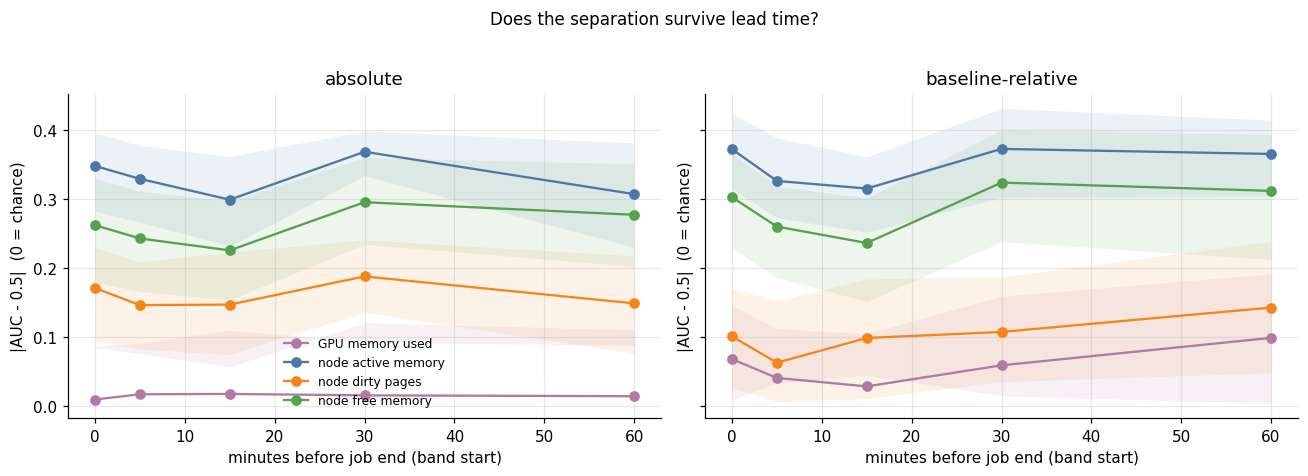

strongest separation in the last 5 min      : 0.372
strongest separation 15+ min before the end : 0.373
-> PRECURSOR: the signal exists with lead time


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, kind in zip(axes, ["absolute", "baseline-relative"]):
    sub = L[L.kind == kind]
    for met, c in zip(sorted(sub.metric.unique()),
                      ["#b279a2", "#4c78a8", "#f58518", "#54a24b"]):
        m = sub[sub.metric == met].sort_values("lead_min")
        ax.plot(m.lead_min, m.sep, "o-", color=c, label=met)
        ax.fill_between(m.lead_min, np.abs(m.lo - .5), np.abs(m.hi - .5),
                        color=c, alpha=.10, lw=0)
    ax.set(xlabel="minutes before job end (band start)", title=kind,
           ylabel="|AUC - 0.5|  (0 = chance)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Does the separation survive lead time?", y=1.02, fontsize=11)
plt.tight_layout(); save(fig, "06_oom_leadtime.png"); plt.show()

near = L[(L.lead_min == 0)].sep.max()
far  = L[(L.lead_min >= 15)].sep.max() if (L.lead_min >= 15).any() else np.nan
facts["sep_last_5min"] = float(near)
facts["sep_beyond_15min"] = float(far) if far == far else None
facts["precursor_survives_lead"] = bool(far == far and far > 0.15)
print(f"strongest separation in the last 5 min      : {near:.3f}")
print(f"strongest separation 15+ min before the end : {far:.3f}")
print(f"-> {'PRECURSOR: the signal exists with lead time' if facts['precursor_survives_lead'] else 'DEATH SIGNATURE: it collapses once we step back'}")

## Step 7 - Verdict

In [11]:
json.dump(facts, open(DATA / "facts_oom.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:32s} {v}")
print(f"\n[{time.time()-t0:.0f}s total]")

oom_jobs_analysed                62
oom_jobs_exclusive               12
best_separation                  0.3712973098770008
O2_baseline_beats_absolute       True
any_interval_excludes_chance     True
sep_last_5min                    0.3721883957265699
sep_beyond_15min                 0.3725432921119446
precursor_survives_lead          True

[14s total]


### How to read this

Whichever way the curves fall, the sample size is the constraint and it cannot be
fixed from this dataset: 130 OOM jobs exist in total, and the ones with enough
telemetry to show a trend are fewer still.

If the OOM trace separates, the conclusion is that a **precursor exists and this
project's features were the wrong shape** - levels instead of baseline-relative
changes - which is a concrete, testable direction and an honest explanation of why
the telemetry models underperformed.

If the traces overlap, the conclusion is stronger for being negative: the failure
mode with the clearest physical mechanism, measured by the sensor that directly
observes that mechanism, shows no precursor on this cluster. That is worth stating
plainly, because it bounds what node-level telemetry can be expected to do here -
and it is exactly the claim that a reader would otherwise assume had never been
checked.